<a href="https://www.kaggle.com/code/lalit7881/iran-vs-us-conflict-news-analysis-eda-99?scriptVersionId=332053617" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

# Import necessary libraries
import numpy as np
import pandas as pd

import matplotlib
matplotlib.use('Agg')  # Use Agg backend
import matplotlib.pyplot as plt
plt.switch_backend('Agg')  # Switch backend if needed

# Ensure inline plotting if running in a Jupyter environment with inline support
%matplotlib inline

import seaborn as sns

# Import sklearn libraries for the prediction model
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc

# Set default Seaborn style
sns.set(style='whitegrid')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/solowpm23/iran-vs-us-coflict-news-dataset/iran_us_news_dataset.csv


## Loading dataset

In [2]:
from pathlib import Path

DATA_ROOTS = [
    Path('/kaggle/input'),
    Path('/kaggle/input'),
    Path('/kaggle/input/datasets'),
]

def resolve_data_file(file_name=None, suffixes=None):
    """
    Helper function to dynamically resolve the data file path.
    This is useful on Kaggle where absolute paths may vary.
    """
    suffixes = tuple(suffixes or [])
    for root in DATA_ROOTS:
        if not root.exists():
            continue
        matches = [p for p in root.rglob('*') if p.is_file()]
        if file_name:
            exact = [p for p in matches if p.name == file_name]
            if exact:
                return exact[0]
        if suffixes:
            typed = [p for p in matches if p.suffix.lower() in suffixes]
            if typed:
                return typed[0]
    raise FileNotFoundError(f'Could not resolve data file: {file_name or suffixes}')

# Resolve the data file for the Iran vs US conflict news dataset
data_file = resolve_data_file(file_name='iran_us_news_dataset.csv')

In [3]:
df = pd.read_csv(data_file, encoding='utf-8')

In [4]:
print('Dataframe shape:', df.shape)
print('Columns:', df.columns.tolist())
df.head()

Dataframe shape: (2286, 6)
Columns: ['link', 'title', 'content', 'date', '_source', '_keyword']


,link,title,content,date,_source,_keyword
0,https://www.aljazeera.com/news/2026/6/13/as-ir...,"As Iran and US near a deal, Tehran remembers a...",Iranian authorities say assassinations and str...,2026-06-13T00:00:00,Bing-Al Jazeera,Iran US war 2025
1,https://cryptobriefing.com/qatar-negotiators-t...,Qatar negotiators travel to Tehran to finalize...,Qatari diplomats are shuttling between Washing...,2026-06-14T07:20:27,Bing-Crypto Briefing,Iran US war 2025
2,https://www.hindustantimes.com/videos/world-ne...,"With Trump’s Iran war almost over, Why is US b...","With Trump’s Iran war almost over, Why is US b...",2026-06-14T10:56:36,Bing-Hindustan Times,Iran US war 2025
3,https://www.bbc.co.uk/sounds/play/w1730bn1kjxvhs2,US and Iran indicate a deal to end the war is ...,Available for 29 days\n\nLebanese state media ...,NaN,BBC,Iran US war 2025
4,https://www.bbc.co.uk/news/videos/cn07x7wldxeo,Iran war: How much damage has the US done to I...,How much damage has the US done to Iran's mili...,2026-06-12T17:52:30,BBC,Iran US war 2025


In [5]:
# Since the 'date' column is provided as a string, we infer it as a datetime type
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Check for missing values in date conversion
print('Number of NaT in date:', df['date'].isna().sum())

# Add new features: length of title and content. These features might be useful for further analysis
df['title_length'] = df['title'].astype(str).apply(len)
df['content_length'] = df['content'].astype(str).apply(len)

# Optionally drop duplicate articles if they exist
df.drop_duplicates(inplace=True)

df.info()

Number of NaT in date: 1535
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2286 entries, 0 to 2285
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   link            2286 non-null   object        
 1   title           2286 non-null   object        
 2   content         2286 non-null   object        
 3   date            751 non-null    datetime64[ns]
 4   _source         2286 non-null   object        
 5   _keyword        2286 non-null   object        
 6   title_length    2286 non-null   int64         
 7   content_length  2286 non-null   int64         
dtypes: datetime64[ns](1), int64(2), object(5)
memory usage: 143.0+ KB


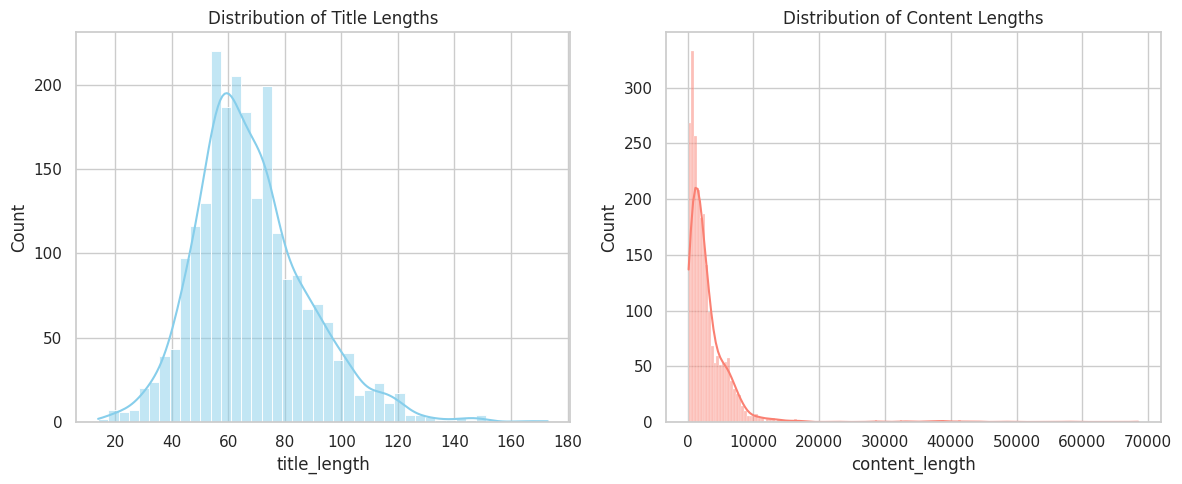

In [6]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['title_length'], kde=True, color='skyblue')
plt.title('Distribution of Title Lengths')

plt.subplot(1, 2, 2)
sns.histplot(df['content_length'], kde=True, color='salmon')
plt.title('Distribution of Content Lengths')

plt.tight_layout()
plt.show()


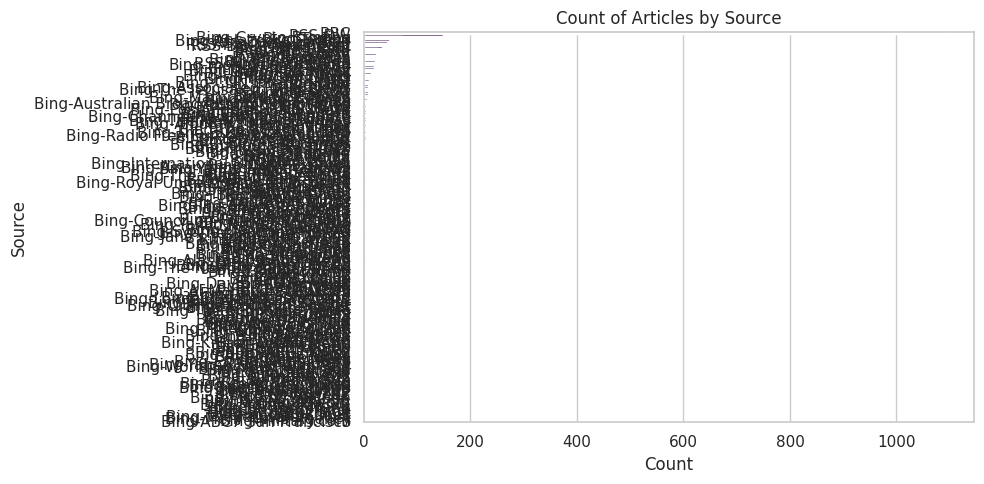

In [7]:
## Count plot of news sources
plt.figure(figsize=(10, 5))
sns.countplot(y=df['_source'], order=df['_source'].value_counts().index, palette='viridis')
plt.title('Count of Articles by Source')
plt.xlabel('Count')
plt.ylabel('Source')
plt.tight_layout()
plt.show()


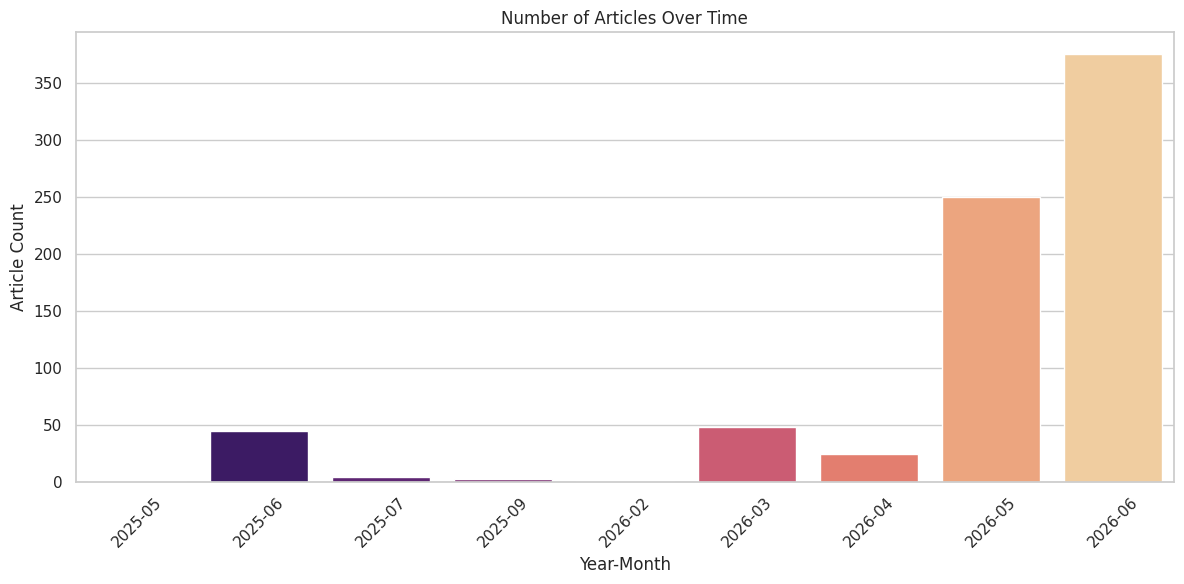

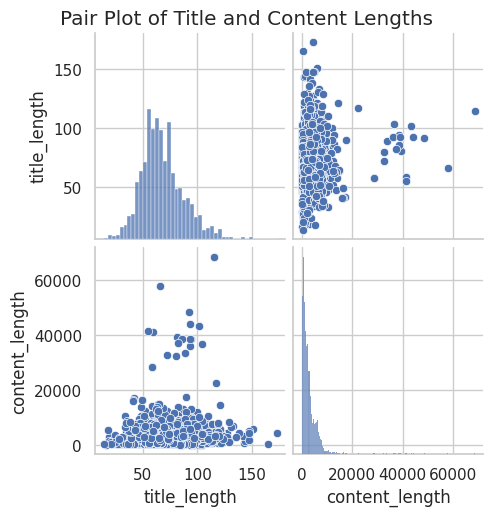

In [8]:
plt.figure(figsize=(12, 6))
if df['date'].notnull().any():
    df['year_month'] = df['date'].dt.to_period('M')
    source_date = df.groupby('year_month').size().reset_index(name='counts')
    source_date['year_month'] = source_date['year_month'].astype(str)
    sns.barplot(x='year_month', y='counts', data=source_date, palette='magma')
    plt.title('Number of Articles Over Time')
    plt.xlabel('Year-Month')
    plt.ylabel('Article Count')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print('No valid dates to plot time series analysis.')

## Pair Plot for the derived numeric features
sns.pairplot(df[['title_length', 'content_length']])
plt.suptitle('Pair Plot of Title and Content Lengths', y=1.02)
plt.show()

Prediction Accuracy: 0.9978165938864629


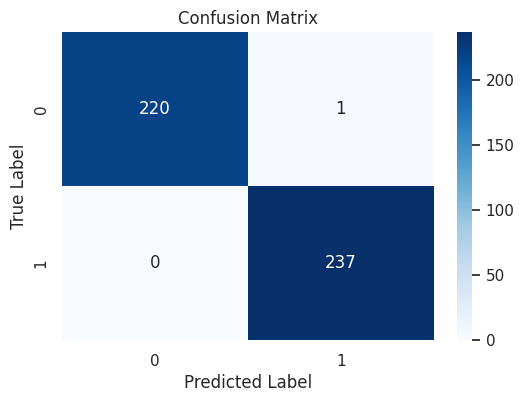

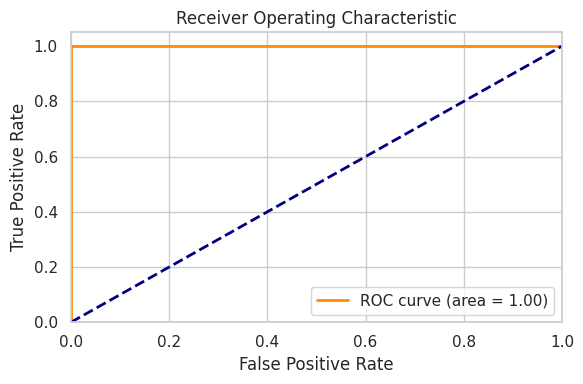

In [9]:
median_length = df['content_length'].median()
df['long_content'] = (df['content_length'] > median_length).astype(int)

# Features: we are using title_length and content_length as predictors
features = ['title_length', 'content_length']
X = df[features]
y = df['long_content']

# Split into train-test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train a logistic regression model
model = LogisticRegression()
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print('Prediction Accuracy:', acc)

# Compute and plot the confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# Compute ROC Curve and AUC
y_probs = model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


## Thank you...pls upvote!!!!!!!!!!!